<a href="https://colab.research.google.com/github/hemasree15-tech/DataScience/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = pd.read_csv('creditcard.csv')

In [7]:
from google.colab import files
uploaded = files.upload()  # upload kaggle.json

In [8]:
import pandas as pd
import numpy as np

# Create sample credit card fraud dataset
np.random.seed(42)
n = 10000
data = {
    'Time': np.random.randint(0, 172800, n),
    'Amount': np.random.exponential(50, n)
}
for i in range(1, 29):
    data[f'V{i}'] = np.random.normal(0, 1, n)

# 2% fraud rate
data['Class'] = np.random.choice([0, 1], n, p=[0.98, 0.02])
df = pd.DataFrame(data)
df.to_csv('creditcard.csv', index=False)
print("✅ Dataset created!", df.shape)
print("Fraud cases:", df['Class'].sum())

✅ Dataset created! (10000, 31)
Fraud cases: 194


In [9]:
dataset.shape

(10000, 31)

In [10]:
dataset.isna().sum()

,0
Time,0
Amount,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0


In [11]:
dataset.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,121958,55.703447,-2.313859,0.605686,0.962811,-0.360071,-1.384809,1.358554,0.530673,-1.280869,...,-0.961674,0.655930,1.299690,0.351254,-1.131966,1.187744,-0.928781,-0.978599,-0.543341,0
1,146867,25.071920,0.020590,-0.049605,0.301853,-1.082595,-1.290182,-0.227487,-0.290769,-0.147117,...,-0.081520,1.667331,-0.243686,-0.690817,0.056928,-0.012482,1.354487,-1.353796,-0.172644,0
2,131932,0.064263,0.301792,-0.164696,-0.845411,-0.207132,1.153584,-0.820596,1.581649,0.013357,...,-2.203670,-0.524999,-0.862838,-1.234923,-1.370951,-0.369183,0.014480,1.703524,-1.258628,0
3,103694,6.400718,-0.512493,-1.107200,-0.613660,1.349360,-0.879467,-1.342803,-2.526512,1.345913,...,1.117179,0.168233,-0.310428,-0.363952,-0.119045,-1.349367,-1.331297,-0.575423,-1.140834,0
4,119879,38.238018,-1.154637,-0.821287,-0.932660,-0.904871,0.369161,0.181057,-1.551648,0.856511,...,1.007726,0.523766,-0.215739,0.422013,-0.784941,0.196971,0.640914,0.848113,-1.278296,1


In [12]:
pd.value_counts(dataset['Class'])

/tmp/ipykernel_3910/2551589613.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(dataset['Class'])


,count
Class,
0,9806
1,194


<Axes: ylabel='count'>

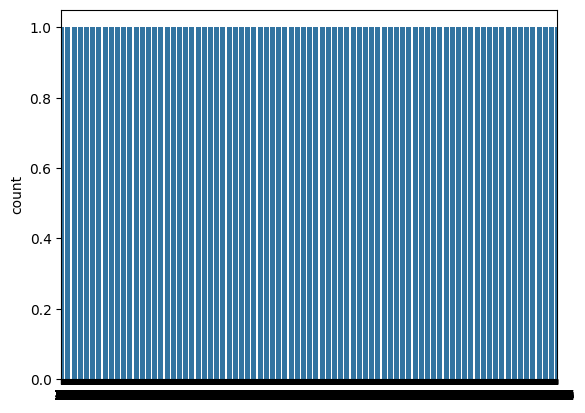

In [13]:
sns.countplot(dataset['Class'])

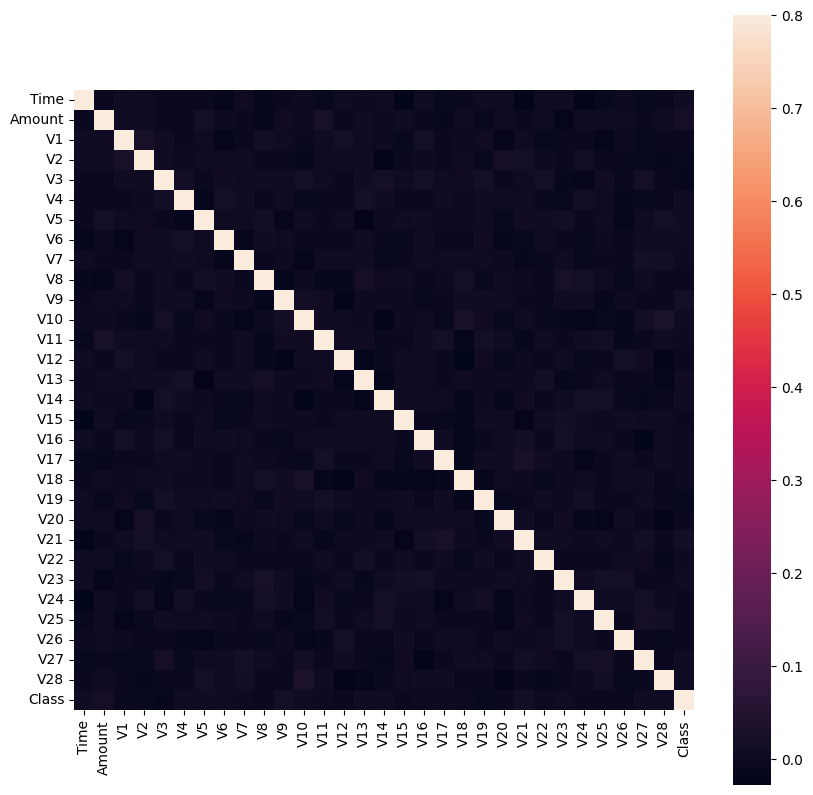

In [14]:
corrmat = dataset.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corrmat , vmax=0.8 , square=True)
plt.show()

In [15]:
len(dataset[dataset['Class']==0]) #valid transaction

9806

In [16]:
len(dataset[dataset['Class']==1]) #fradulent transactions

194

In [17]:
X = dataset.iloc[: , :-1].values
y = dataset.iloc[: , -1].values

In [19]:
#convert imbalanced data to balanced data
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
x_res , y_res = ros.fit_resample(X,y)

In [20]:
X.shape

(10000, 30)

In [21]:
x_res.shape

(19612, 30)

In [22]:
from collections import Counter
print(Counter(y))
print(Counter(y_res))

Counter({np.int64(0): 9806, np.int64(1): 194})
Counter({np.int64(0): 9806, np.int64(1): 9806})


In [23]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x_res , y_res , test_size=0.3 , random_state=42)

In [24]:
x_train.shape

(13728, 30)

In [25]:
y_train.shape

(13728,)

In [26]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 641 , random_state=0)
classifier.fit(x_train , y_train)

RandomForestClassifier(n_estimators=641, random_state=0)

In [27]:
y_pred = classifier.predict(x_test)

In [28]:
n_errors = (y_pred != y_test).sum()

In [29]:
n_errors

np.int64(0)

In [30]:
y_test.shape

(5884,)

1.0


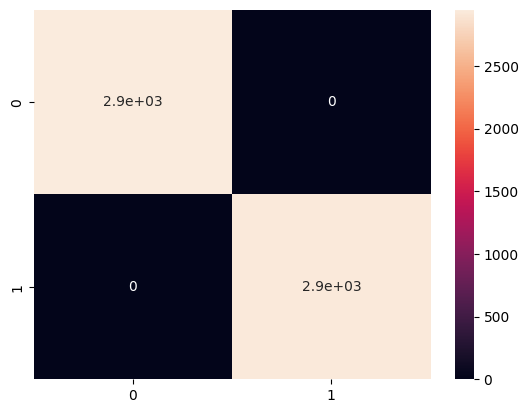

In [31]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test , y_pred)
sns.heatmap(cm , annot=True)
print(accuracy_score(y_test , y_pred))

In [32]:
from sklearn.metrics import precision_score
precision_score(y_test , y_pred)

1.0

In [33]:
from sklearn.metrics import recall_score
recall_score(y_test , y_pred)

1.0

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2949
           1       1.00      1.00      1.00      2935

    accuracy                           1.00      5884
   macro avg       1.00      1.00      1.00      5884
weighted avg       1.00      1.00      1.00      5884



In [35]:
#Thank you!!